To use this script, label the grains interiors with magenta in image j (or you can change the color threshold to something other than magenta, imagej will tell you the value), and the boundaries with white. Anything unlabelled gets mapped to background

uint8 0 217
[  0   1   2   3   4   5   6   7   8  10  11  12  13  14  15  16  17  19
  20  21  22  23  24  25  26  28  29  30  31  32  33  34  35  37  38  39
  40  41  42  43  44  46  47  48  49  50  51  52  53  55  56  57  58  59
  60  61  62  64  65  66  67  68  69  70  71  73  74  75  76  77  78  79
  80  82  83  84  85  86  87  88  89  91  92  93  94  95  96  97  98 100
 101 102 103 104 105 106 107 109 110 111 112 113 114 115 116 118 119 120
 121 122 123 124 125 127 128 129 130 131 132 133 134 136 137 138 139 140
 141 142 143 145 146 147 148 149 150 151 152 154 155 156 157 158 159 160
 161 163 164 165 166 167 168 169 170 172 173 174 175 176 177 178 179 181
 182 183 184 185 186 187 188 190 191 192 193 194 195 196 197 199 200 201
 202 203 205 206 209 210 211 214 217]
Most frequent pixel values:
Value 80: 53810 pixels
Value 89: 41532 pixels
Value 71: 35510 pixels
Value 82: 26873 pixels
Value 79: 26715 pixels
Value 84: 26335 pixels
Value 83: 26297 pixels
Value 78: 25799 pixels
Value 85

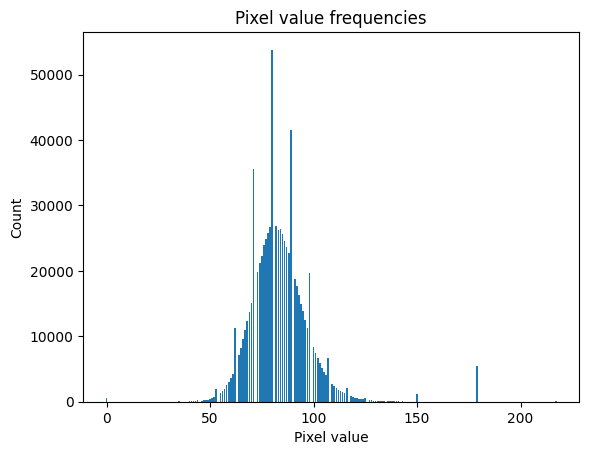

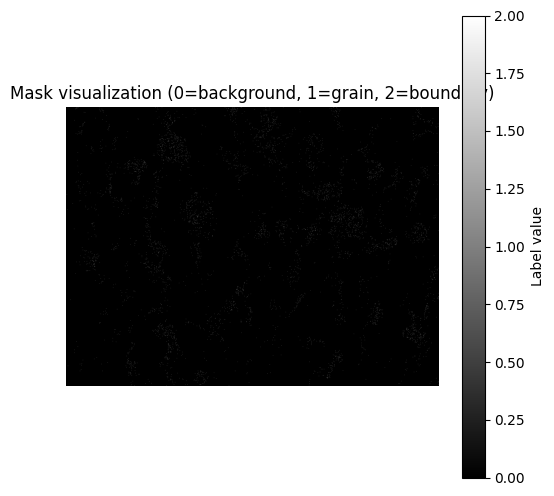

Grain interior pixels (1): 4547
Grain boundary pixels (2): 0
Mask remapped


In [4]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

name="20251009-Imperfect images & Doped sample/Doped sample/Wilson180_0.25%_surface1_09.tif"
name="20250828_Alumina_SEM (1)/prac7_etched_010.tif"
# Load grayscale image
img = cv2.imread(name, cv2.IMREAD_GRAYSCALE)
grain_bound=255 #don't agree with imagej but seem to work
grain_interior=105
print(img.dtype, img.min(), img.max())
print(np.unique(img))

unique, counts = np.unique(img, return_counts=True)

# Combine and sort by count descending
value_counts = sorted(zip(unique, counts), key=lambda x: x[1], reverse=True)

print("Most frequent pixel values:")
for val, cnt in value_counts[:10]:
    print(f"Value {val}: {cnt} pixels")

plt.bar([v for v, c in value_counts], [c for v, c in value_counts]) #plot values, for debugging color issue
plt.xlabel("Pixel value")
plt.ylabel("Count")
plt.title("Pixel value frequencies")
plt.show()

# Create output label image (same size, integer labels)
labels = np.zeros_like(img, dtype=np.uint8) #sets everything to zero at the start

# Apply thresholding / labeling
labels[img == grain_interior] = 1
labels[img == grain_bound] = 2

# Build output filename: <originalname>_mask.tif
directory, filename = os.path.split(name)
base, ext = os.path.splitext(filename)

output_filename = f"{base}_mask{ext}"
output_path = os.path.join(directory, output_filename)

# Save result
cv2.imwrite(output_path, labels)


# Grayscale visualization (1–2 mapped properly)
plt.figure(figsize=(6, 6))
plt.imshow(labels, cmap="gray", vmin=0, vmax=2)
plt.colorbar(label="Label value")
plt.title("Mask visualization (0=background, 1=grain, 2=boundary)")
plt.axis("off")
plt.show()

num_grain_pixels = np.sum(labels == 1)
num_boundary_pixels = np.sum(labels == 2)

print(f"Grain interior pixels (1): {num_grain_pixels}")
print(f"Grain boundary pixels (2): {num_boundary_pixels}")

print("Mask remapped")
